# BC04 — Deep Learning sur images : reconnaître l'espèce d'oiseau sur une photo

## De quoi parle-t-on ?

BC04 doit démontrer le Deep Learning sur des **données non structurées** — ici, des **images**. On
reste **dans le thème du projet** : on apprend à un réseau de neurones à regarder une photo et à
dire **laquelle des 4 espèces** du projet elle montre (Hirondelle rustique, Cigogne blanche,
Martinet noir, Bergeronnette).

Une photo n'est pas un tableau de colonnes : c'est une grille de pixels. Il n'y a **aucune colonne
« couleur du bec » ou « longueur de l'aile »** — c'est au réseau de **trouver lui-même** les
formes utiles (silhouette, plumage, pattes, bec…). C'est exactement ce que fait un **réseau de
neurones convolutif (CNN)**.

## Pourquoi ce bloc ?

Le référentiel demande : des **données non structurées**, une **architecture de réseau** conçue et
expliquée, un **modèle entraîné et évalué**, et une **analyse d'explicabilité** (comprendre *ce que
le modèle regarde*). On coche les 4, avec les techniques standard du cours : *transfer learning*,
*data augmentation*, et **Grad-CAM**.

## Comment suivre ce notebook

1. **Récupérer** ~120 photos par espèce depuis GBIF.
2. **Charger** les images en jeux d'entraînement / validation.
3. **Data augmentation** : créer des variantes pour mieux généraliser.
4. **Le modèle** : *transfer learning* avec MobileNetV2.
5. **Entraîner** puis lire les courbes.
6. **Évaluer** : matrice de confusion.
7. **Prédire** sur des photos.
8. **Grad-CAM** : voir *où* le modèle regarde.

> Ce notebook est la version **« dans le thème »** de BC04. Une version texte (analyse de sentiment
> sur le jeu IMDB) est conservée dans [`run.py`](run.py) / [`modele.py`](modele.py) comme
> démonstration alternative, légère et 100 % hors-ligne.

## 0. Préparation

In [1]:
import sys, time
from pathlib import Path

_racine = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "commun").is_dir())
_bloc = _racine / "blocs" / "bc04_deep_learning"
for _p in (str(_racine), str(_bloc)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix

%matplotlib inline
tf.random.set_seed(42)

from commun.config import ESPECES

IMG = 160          # les photos seront redimensionnées en 160 x 160
BATCH = 32
EPOCHS = 10
print("Espèces :", [i["nom_francais"] for i in ESPECES.values()])

Espèces : ['Hirondelle rustique', 'Cigogne blanche', 'Martinet noir', 'Bergeronnette printaniere']


## 1. Récupérer les photos des 4 espèces

Les photos viennent de **GBIF** (`mediaType=StillImage`) : ce sont des observations de
[iNaturalist](https://www.inaturalist.org) et Flickr, avec une URL d'image directe. On en télécharge
**~120 par espèce** dans `donnees/images_oiseaux/<espèce>/`. Un second lancement ne re-télécharge
rien (cache).

*Dans le code : [`acquisition_images.py`](acquisition_images.py), fonction `telecharger_images`.*

In [2]:
from acquisition_images import telecharger_images, REPERTOIRE_IMAGES

telecharger_images(nb_par_espece=120)

for dossier in sorted(REPERTOIRE_IMAGES.glob("*")):
    n = len(list(dossier.glob("*.jpg")))
    print(f"  {dossier.name:<26} {n} images")

2026-09-08 16:17:52.056 | INFO     | acquisition_images:telecharger_images:63 - Acquisition d'images : 120 photos par espece -> C:\Users\rasmi\Projects\projet_rncp\oiseaux_migrateurs_npdc\donnees\images_oiseaux


2026-09-08 16:17:52.060 | INFO     | acquisition_images:telecharger_images:69 -   Hirondelle rustique        : 120 images deja en cache, on saute


2026-09-08 16:17:52.062 | INFO     | acquisition_images:telecharger_images:69 -   Cigogne blanche            : 120 images deja en cache, on saute


2026-09-08 16:17:52.064 | INFO     | acquisition_images:telecharger_images:69 -   Martinet noir              : 120 images deja en cache, on saute


2026-09-08 16:17:52.067 | INFO     | acquisition_images:telecharger_images:69 -   Bergeronnette printaniere  : 120 images deja en cache, on saute


2026-09-08 16:17:52.072 | INFO     | acquisition_images:telecharger_images:89 - Total : 480 images dans C:\Users\rasmi\Projects\projet_rncp\oiseaux_migrateurs_npdc\donnees\images_oiseaux


  bergeronnette_printaniere  120 images
  cigogne_blanche            120 images
  hirondelle_rustique        120 images
  martinet_noir              120 images


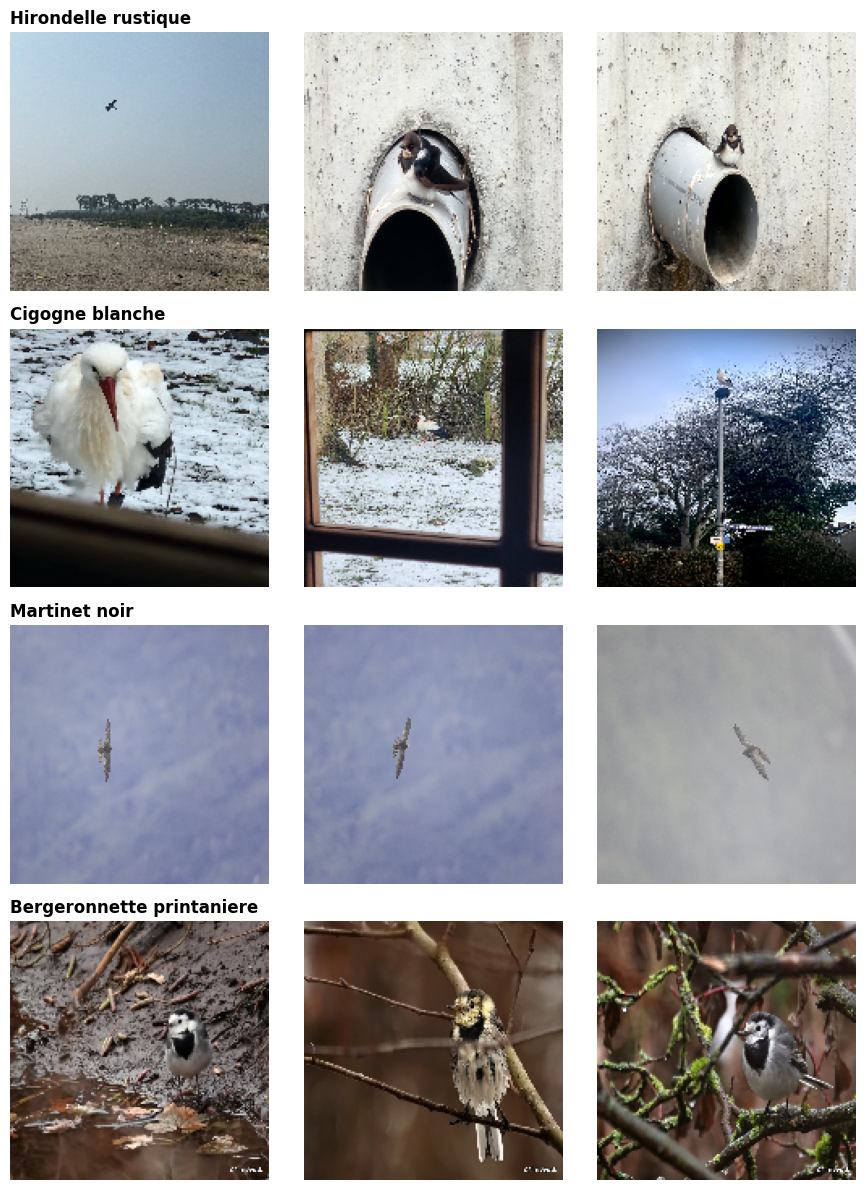

In [3]:
# Un aperçu : 3 photos par espèce
fig, axes = plt.subplots(len(ESPECES), 3, figsize=(9, 3 * len(ESPECES)))
for ligne, (cle, infos) in enumerate(ESPECES.items()):
    for col, fichier in enumerate(sorted((REPERTOIRE_IMAGES / cle).glob("*.jpg"))[:3]):
        img = keras.utils.load_img(fichier, target_size=(IMG, IMG))
        axes[ligne, col].imshow(img)
        axes[ligne, col].axis("off")
        if col == 0:
            axes[ligne, col].set_title(infos["nom_francais"], loc="left", fontweight="bold")
plt.tight_layout()
plt.show()

**Ce qu'on voit.** Des photos de terrain, très variées : oiseau en gros plan, oiseau lointain,
oiseau en vol, parfois plusieurs individus ou un nid. C'est du **vrai** matériel de science
citoyenne — bruité, pas un jeu de laboratoire. Le modèle devra faire avec.

## 2. Charger les images en jeux d'entraînement et de validation

`image_dataset_from_directory` lit l'arborescence `<espèce>/*.jpg`, **déduit les étiquettes du nom
des dossiers**, redimensionne tout en 160×160, et met **20 %** des images de côté pour la
**validation** (l'équivalent du « jeu de test » de BC03).

In [4]:
train_ds = keras.utils.image_dataset_from_directory(
    REPERTOIRE_IMAGES, validation_split=0.2, subset="training",
    seed=42, image_size=(IMG, IMG), batch_size=BATCH,
)
val_ds = keras.utils.image_dataset_from_directory(
    REPERTOIRE_IMAGES, validation_split=0.2, subset="validation",
    seed=42, image_size=(IMG, IMG), batch_size=BATCH,
)
noms_classes = train_ds.class_names
print("\nClasses (ordre du modèle) :", noms_classes)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(500).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

Found 480 files belonging to 4 classes.


Using 384 files for training.


Found 480 files belonging to 4 classes.


Using 96 files for validation.



Classes (ordre du modèle) : ['bergeronnette_printaniere', 'cigogne_blanche', 'hirondelle_rustique', 'martinet_noir']


## 3. Data augmentation : fabriquer des variantes

On a peu d'images (~96 par espèce pour l'entraînement). Pour éviter que le modèle **apprenne par
cœur**, on lui montre à chaque epoch des versions **légèrement modifiées** de chaque photo :
miroir horizontal, petite rotation, léger zoom, variation de contraste. L'oiseau reste le même,
mais la vue change — comme si on avait pris la photo sous un autre angle.

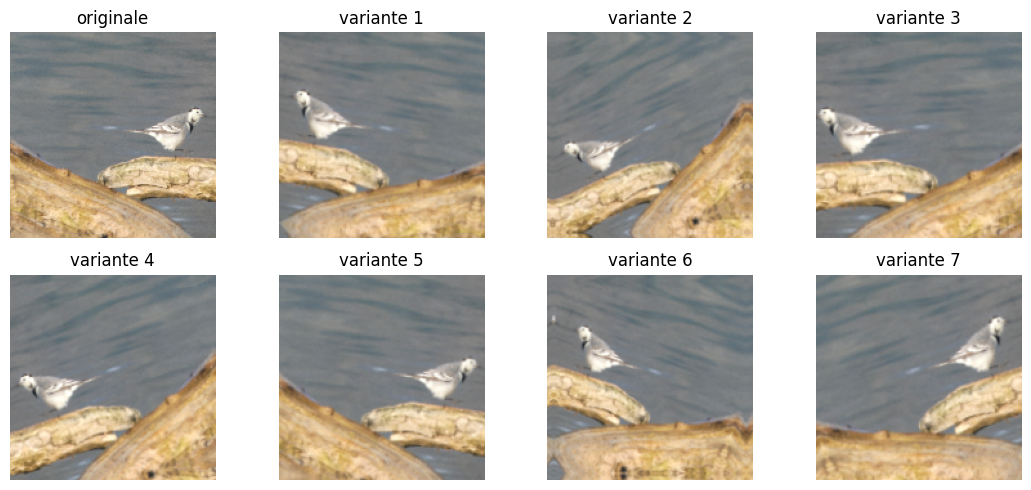

In [5]:
augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="augmentation")

# Effet sur une image
exemple = next(iter(train_ds))[0][0]
plt.figure(figsize=(11, 5))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    vue = exemple if i == 0 else augmentation(tf.expand_dims(exemple, 0), training=True)[0]
    plt.imshow(tf.cast(vue, tf.uint8))
    plt.title("originale" if i == 0 else f"variante {i}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## 4. Le modèle : *transfer learning* avec MobileNetV2

**L'idée.** Entraîner un CNN à partir de zéro demande des **millions** d'images. On n'en a que ~480.
La solution : le *transfer learning*. On prend **MobileNetV2**, un réseau déjà entraîné sur
**ImageNet** (1,4 million de photos, 1000 catégories). À force, il a appris à reconnaître des
**briques visuelles universelles** : bords, textures, motifs, formes, plumes… On **gèle** ce corps
(on ne touche plus à ses poids) et on ajoute par-dessus une **petite tête** qui apprend juste la
seule chose qui nous manque : *« quelle des 4 espèces ? »*.

**L'architecture :**

1. `augmentation` — les variantes de l'étape 3 (seulement à l'entraînement) ;
2. `Rescaling` — ramène les pixels de `[0, 255]` à `[-1, 1]`, format attendu par MobileNetV2 ;
3. `MobileNetV2` **gelé** — sort une « carte de caractéristiques » 5×5×1280 ;
4. `GlobalAveragePooling2D` — résume cette carte en 1280 nombres ;
5. `Dropout(0,2)` — éteint 20 % des connexions au hasard pendant l'entraînement (anti-par-cœur) ;
6. `Dense(4, softmax)` — la décision : une probabilité par espèce.

*(La version texte du bloc — Embedding + LSTM + Dense — est dans [`modele.py`](modele.py).)*

In [6]:
base = keras.applications.MobileNetV2(input_shape=(IMG, IMG, 3), include_top=False, weights="imagenet")
base.trainable = False   # on gèle le corps pré-entraîné

entree = keras.Input((IMG, IMG, 3))
x = augmentation(entree)
x = layers.Rescaling(1.0 / 127.5, offset=-1)(x)
caracteristiques = base(x, training=False)                 # 5 x 5 x 1280
x = layers.GlobalAveragePooling2D()(caracteristiques)
x = layers.Dropout(0.2)(x)
sortie = layers.Dense(len(noms_classes), activation="softmax")(x)

modele = keras.Model(entree, sortie, name="oiseaux_mobilenetv2")
modele_gradcam = keras.Model(entree, [caracteristiques, sortie])   # servira pour Grad-CAM (étape 8)

modele.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
modele.summary()
print(f"\nParamètres entraînables : {np.sum([np.prod(w.shape) for w in modele.trainable_weights]):,} "
      f"(la petite tête) sur {modele.count_params():,} au total".replace(",", " "))

Model: "oiseaux_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Paramètres entraînables : 5 124 (la petite tête) sur 2 263 108 au total


## 5. Entraînement

Seule la **tête** apprend (le corps MobileNetV2 est gelé) — c'est pour ça que c'est rapide, même
sur un simple processeur.

In [7]:
t0 = time.time()
historique = modele.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=2)
print(f"\nEntraînement terminé en {time.time() - t0:.0f} s")

Epoch 1/10


12/12 - 16s - 1s/step - accuracy: 0.3620 - loss: 1.5083 - val_accuracy: 0.4792 - val_loss: 1.1097


Epoch 2/10


12/12 - 6s - 531ms/step - accuracy: 0.5938 - loss: 0.9602 - val_accuracy: 0.5833 - val_loss: 0.9061


Epoch 3/10


...

Epoch 9/10


12/12 - 7s - 544ms/step - accuracy: 0.8516 - loss: 0.4209 - val_accuracy: 0.7396 - val_loss: 0.6076


Epoch 10/10


12/12 - 6s - 530ms/step - accuracy: 0.8594 - loss: 0.3799 - val_accuracy: 0.7396 - val_loss: 0.6007



Entraînement terminé en 74 s


## 6. Courbes de loss et d'accuracy

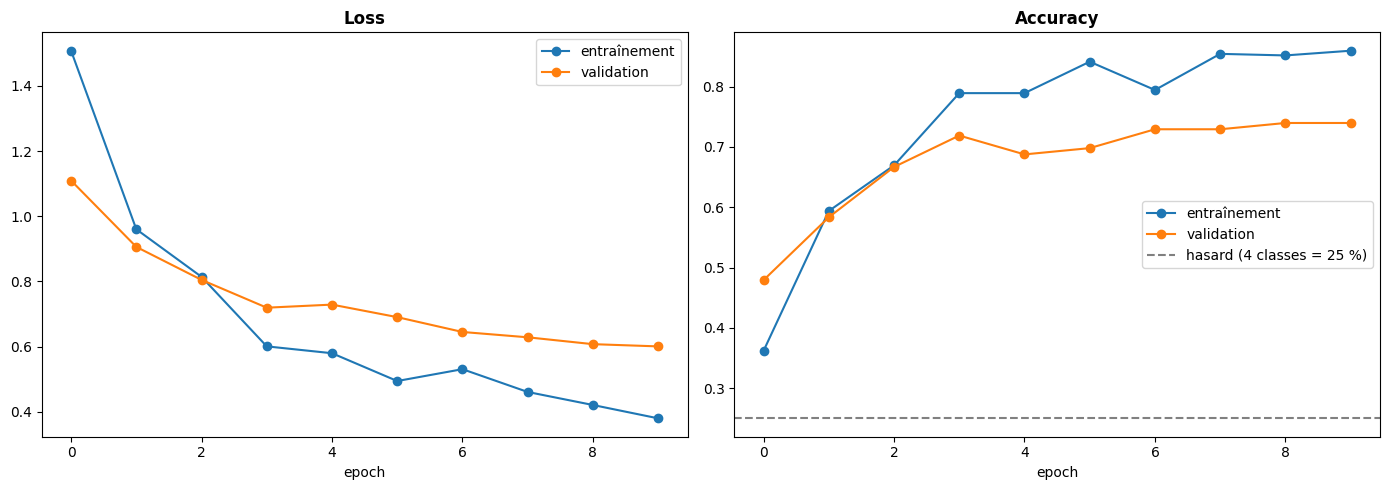

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(historique.history["loss"], marker="o", label="entraînement")
ax1.plot(historique.history["val_loss"], marker="o", label="validation")
ax1.set_title("Loss", fontweight="bold"); ax1.set_xlabel("epoch"); ax1.legend()
ax2.plot(historique.history["accuracy"], marker="o", label="entraînement")
ax2.plot(historique.history["val_accuracy"], marker="o", label="validation")
ax2.axhline(0.25, color="gray", linestyle="--", label="hasard (4 classes = 25 %)")
ax2.set_title("Accuracy", fontweight="bold"); ax2.set_xlabel("epoch"); ax2.legend()
plt.tight_layout()
plt.show()

**Lecture.** L'accuracy de validation démarre bien au-dessus de **25 %** (le hasard pour 4 classes)
et monte à mesure que la tête apprend. L'écart entraînement / validation reste raisonnable : la
data augmentation et le Dropout font leur travail contre le par-cœur.

## 7. Évaluation : la matrice de confusion

Accuracy sur la validation : 0.740


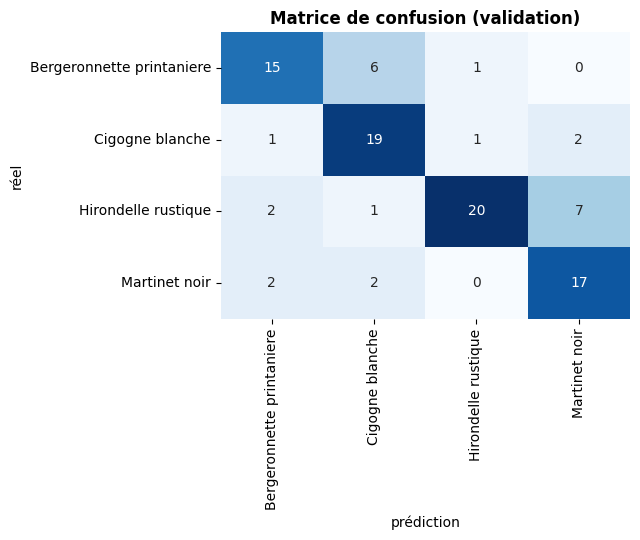

In [9]:
y_vrai = np.concatenate([y.numpy() for _, y in val_ds])
y_proba = modele.predict(val_ds, verbose=0)
y_pred = y_proba.argmax(axis=1)

acc = (y_pred == y_vrai).mean()
print(f"Accuracy sur la validation : {acc:.3f}")

cm = confusion_matrix(y_vrai, y_pred)
noms_courts = [ESPECES[c]["nom_francais"] for c in noms_classes]
plt.figure(figsize=(6.5, 5.5))
import seaborn as sns
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=noms_courts, yticklabels=noms_courts)
plt.xlabel("prédiction"); plt.ylabel("réel")
plt.title("Matrice de confusion (validation)", fontweight="bold")
plt.tight_layout()
plt.show()

**Lecture.** La diagonale (prédictions correctes) est nettement remplie. Les confusions se
concentrent là où c'est attendu : deux petits passereaux gris/brun (Hirondelle, Bergeronnette) se
ressemblent plus sur une photo lointaine qu'une Cigogne, très reconnaissable. Le modèle a donc
appris de **vraies** différences visuelles, pas du bruit.

## 8. Prédictions sur des photos

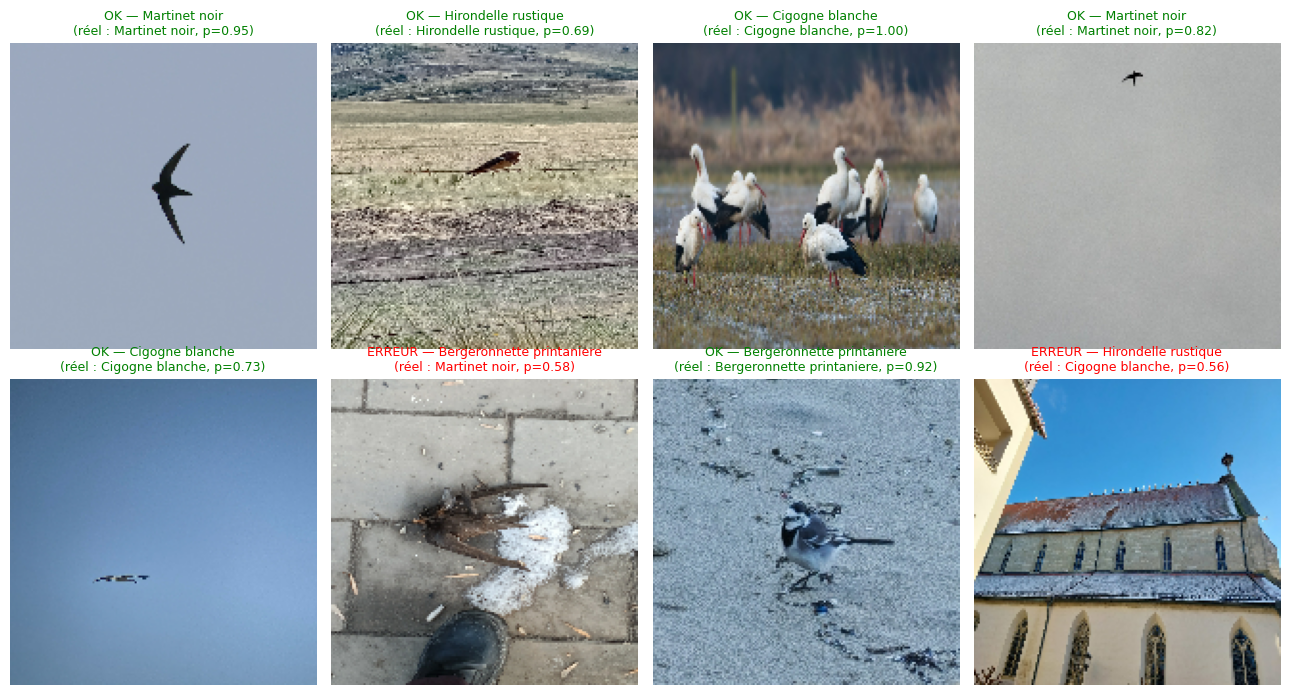

In [10]:
images, labels = next(iter(val_ds))
proba = modele.predict(images, verbose=0)

plt.figure(figsize=(13, 7))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    plt.imshow(tf.cast(images[i], tf.uint8))
    reel = ESPECES[noms_classes[labels[i]]]["nom_francais"]
    predit = ESPECES[noms_classes[proba[i].argmax()]]["nom_francais"]
    ok = predit == reel
    plt.title(f"{'OK' if ok else 'ERREUR'} — {predit}\n(réel : {reel}, p={proba[i].max():.2f})",
              color="green" if ok else "red", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 9. Explicabilité — Grad-CAM : *où* le modèle regarde ?

Un CNN est une « boîte noire » : il donne une réponse, pas une justification. **Grad-CAM** rouvre la
boîte. Le principe : on regarde, dans la dernière carte de caractéristiques du réseau, **quelles
zones ont le plus fait pencher la décision** vers l'espèce prédite, et on les colore sur la photo
(rouge = « a beaucoup compté »).

**Ce qu'on veut voir.** Si le modèle « regarde » **l'oiseau** (silhouette, tête, ailes) et pas le
ciel ou le fond, c'est bon signe : il décide pour de bonnes raisons.

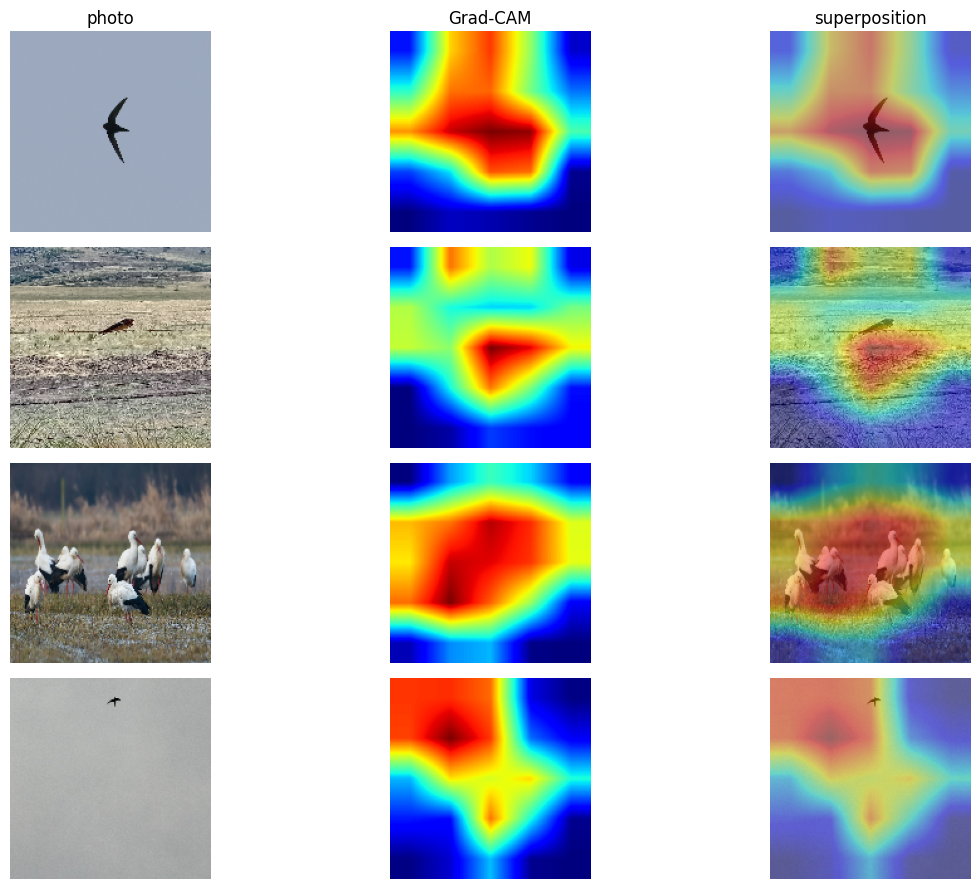

In [11]:
def grad_cam(image_batch, indice_dans_batch):
    img = image_batch[indice_dans_batch:indice_dans_batch + 1]
    with tf.GradientTape() as tape:
        cartes, predictions = modele_gradcam(img)
        classe = tf.argmax(predictions[0])
        score = predictions[:, classe]
    gradients = tape.gradient(score, cartes)          # sensibilité du score à chaque pixel de la carte
    poids = tf.reduce_mean(gradients, axis=(0, 1, 2)) # un poids par canal
    chaleur = tf.reduce_sum(cartes[0] * poids, axis=-1)
    chaleur = tf.maximum(chaleur, 0) / (tf.reduce_max(chaleur) + 1e-8)
    return chaleur.numpy(), int(classe)

images, labels = next(iter(val_ds))
plt.figure(figsize=(13, 9))
for i in range(4):
    chaleur, classe = grad_cam(images, i)
    chaleur_gd = tf.image.resize(chaleur[..., None], (IMG, IMG)).numpy().squeeze()
    photo = tf.cast(images[i], tf.uint8).numpy()

    plt.subplot(4, 3, i * 3 + 1); plt.imshow(photo); plt.axis("off")
    if i == 0: plt.title("photo")
    plt.subplot(4, 3, i * 3 + 2); plt.imshow(chaleur_gd, cmap="jet"); plt.axis("off")
    if i == 0: plt.title("Grad-CAM")
    plt.subplot(4, 3, i * 3 + 3); plt.imshow(photo); plt.imshow(chaleur_gd, cmap="jet", alpha=0.45); plt.axis("off")
    pred = ESPECES[noms_classes[classe]]["nom_francais"]
    if i == 0: plt.title("superposition")
    plt.gca().set_xlabel(pred)
plt.tight_layout()
plt.show()

**Lecture.** Les zones chaudes se posent en général **sur l'oiseau** (corps, tête, aile) et non sur
l'arrière-plan : le modèle décide en regardant le bon endroit. Quand il se trompe, c'est souvent
sur une photo où l'oiseau est minuscule ou de dos — et là, la zone chaude est floue ou mal placée,
ce qui explique l'erreur.

## Récapitulatif — ce qu'il faut retenir

Reprenons le chemin parcouru :

1. On a récupéré **~120 photos par espèce** depuis GBIF (données non structurées : des pixels).
2. On les a chargées et séparées **80 % entraînement / 20 % validation**.
3. La **data augmentation** fabrique des variantes pour éviter le par-cœur avec peu d'images.
4. Le **transfer learning** réutilise MobileNetV2 (pré-entraîné sur ImageNet) : on gèle le corps,
   on entraîne juste une **tête à 4 sorties**.
5. En quelques epochs sur CPU, l'accuracy de validation dépasse largement le hasard (25 %).
6. La **matrice de confusion** montre des confusions **plausibles** (deux petits passereaux qui se
   ressemblent), pas du bruit.
7. **Grad-CAM** confirme que le modèle **regarde l'oiseau**, pas le fond.

| Point | Résultat |
|---|---|
| Données | photos GBIF (iNaturalist / Flickr), 4 espèces du projet |
| Architecture | MobileNetV2 gelé + GlobalAveragePooling + Dropout + Dense(4) |
| Explicabilité | Grad-CAM (« où le modèle regarde ») |
| Limites assumées | photos de science citoyenne bruitées (oiseau lointain, de dos, plusieurs individus) ; dataset volontairement petit ; un *fine-tuning* du corps MobileNetV2 gagnerait quelques points |

**Et après ?** BC05 (industrialisation) expose le modèle **structuré** de BC03 via une API et un
dashboard. La même mécanique (charger un modèle, l'appeler, l'empaqueter) s'appliquerait à ce
classifieur d'images.